In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.listdir("/content/drive/MyDrive/")

["Chrome'dan kaydedildi",
 'Classroom',
 'Birinde grafiki biz yaradirig diyerinde yox ele mi....gdoc',
 'Colab Notebooks',
 'DATA']

In [3]:
# Train Data

import zipfile

zip_path = "/content/drive/MyDrive/DATA/training_set.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

training_set = train_datagen.flow_from_directory(
    "/content/dataset/training_set",
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary'
)

print("Data loaded successfully!")

Found 8000 images belonging to 2 classes.
Data loaded successfully!


In [5]:
# Test data

zip_path = "/content/drive/MyDrive/DATA/test_set.zip"  # Update path
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(rescale=1./255)

test_set = test_datagen.flow_from_directory(
    "/content/dataset/test_set",
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary'
)

print("Data loaded successfully!")

Found 2000 images belonging to 2 classes.
Data loaded successfully!


In [7]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.1 MB/s eta 0:00:00


In [8]:
import tensorflow as tf


import optuna
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten,  Dropout, SpatialDropout2D
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adadelta, Nadam

from tensorflow.keras.preprocessing.image import ImageDataGenerator

import os
import numpy as np
import pandas as pd

from tensorflow.keras.preprocessing import image


In [9]:
from sklearn.metrics import roc_auc_score


In [10]:
def create_model(trial):
    model = Sequential()

    """ Convolutional Neural Network """

    filters1 = trial.suggest_int('filters1', 16, 64)
    filters2 = trial.suggest_int('filters2', 16, 64)
    kernel_size = trial.suggest_int('kernel_size', 2, 5)
    pool_size = trial.suggest_int('pool_size', 2, 3)
    strides = trial.suggest_int('strides', 1, 2)
    spatial_dropout_conv1 = trial.suggest_float("dropout_conv1", 0.1, 0.5)
    spatial_dropout_conv2 = trial.suggest_float("dropout_conv2", 0.1, 0.5)

    model.add(Conv2D(filters=filters1, kernel_size=kernel_size, activation='relu', input_shape=[64, 64, 3]))
    model.add(MaxPool2D(pool_size=pool_size, strides=strides))
    model.add(SpatialDropout2D(spatial_dropout_conv1))

    model.add(Conv2D(filters=filters2, kernel_size=kernel_size, activation='relu'))
    model.add(MaxPool2D(pool_size=pool_size, strides=strides))
    model.add(SpatialDropout2D(spatial_dropout_conv2))

    model.add(Flatten())

    """ Artificial Neural Network """

    model.add(Dense(units=trial.suggest_int('units_layer1', 6, 64), activation='relu'))
    model.add(Dropout(trial.suggest_float("dropout_ann1", 0.1, 0.5)))

    model.add(Dense(units=trial.suggest_int('units_layer2', 6, 64), activation='relu'))
    model.add(Dropout(trial.suggest_float("dropout_ann2", 0.1, 0.5)))

    model.add(Dense(units=1, activation='sigmoid'))

    """ Suggest hyperparameters for the optimizer """
    optimizer_name = trial.suggest_categorical('optimizer', ['adam', 'sgd', 'rmsprop', 'adagrad'])
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True)

    if optimizer_name == 'adam':
        optimizer = Adam(learning_rate=learning_rate)
    elif optimizer_name == 'sgd':
        optimizer = SGD(learning_rate=learning_rate)
    elif optimizer_name == 'rmsprop':
        optimizer = RMSprop(learning_rate=learning_rate)
    elif optimizer_name == 'adagrad':
        optimizer = Adagrad(learning_rate=learning_rate)

    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['AUC'])

    return model


In [11]:
from optuna.samplers import TPESampler

def optimal(trial):
    model = create_model(trial)

    history = model.fit(training_set, validation_data=test_set, epochs=10, batch_size=trial.suggest_int('batch_size', 16, 64))

    test_loss, test_accuracy = model.evaluate(test_set, verbose=0)

    return test_accuracy

tpe_sampler = TPESampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=tpe_sampler)

study.optimize(optimal, n_trials=2)

print(f"Best trial: {study.best_trial.value}")
print(f"Best hyperparameters: {study.best_trial.params}")

[I 2026-04-26 15:53:10,871] A new study created in memory with name: no-name-d4193175-16bb-4f6a-92f7-18763f3e3d8f
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 38s 118ms/step - AUC: 0.5198 - loss: 0.6977 - val_AUC: 0.5905 - val_loss: 0.6923
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 26s 104ms/step - AUC: 0.5282 - loss: 0.6916 - val_AUC: 0.6450 - val_loss: 0.6897
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 97ms/step - AUC: 0.5701 - loss: 0.6845 - val_AUC: 0.7084 - val_loss: 0.6662
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 26s 104ms/step - AUC: 0.5974 - loss: 0.6762 - val_AUC: 0.7191 - val_loss: 0.6630
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 26s 104ms/step - AUC: 0.6249 - loss: 0.6653 - val_AUC: 0.7333 - val_loss: 0.6494
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 27s 110ms/step - AUC: 0.6536 - loss: 0.6527 - val_AUC: 0.7573 - val_loss: 0.6307
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 26s 102ms/step - AUC: 0.6636 - loss: 0.6462 - val_AUC: 0.7656 - val_loss: 0.6304
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 25s 101ms/step - AUC: 0.6823 - loss: 0.6373 - val_AUC: 0.7597 - val_loss: 0.6318
Epoch 9/10
250/250 ━━━━━━━━━━━━━━

[I 2026-04-26 15:57:47,591] Trial 0 finished with value: 0.7843875288963318 and parameters: {'filters1': 34, 'filters2': 62, 'kernel_size': 4, 'pool_size': 3, 'strides': 1, 'dropout_conv1': 0.16239780813448107, 'dropout_conv2': 0.12323344486727979, 'units_layer1': 57, 'dropout_ann1': 0.34044600469728353, 'units_layer2': 47, 'dropout_ann2': 0.10823379771832098, 'optimizer': 'adam', 'learning_rate': 3.5498788321965036e-05, 'batch_size': 30}. Best is trial 0 with value: 0.7843875288963318.


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 35s 114ms/step - AUC: 0.5147 - loss: 0.6964 - val_AUC: 0.6661 - val_loss: 0.6900
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 26s 105ms/step - AUC: 0.5254 - loss: 0.6933 - val_AUC: 0.6617 - val_loss: 0.6851
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 26s 105ms/step - AUC: 0.5432 - loss: 0.6916 - val_AUC: 0.6739 - val_loss: 0.6852
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 27s 106ms/step - AUC: 0.5354 - loss: 0.6902 - val_AUC: 0.6903 - val_loss: 0.6783
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 25s 102ms/step - AUC: 0.5637 - loss: 0.6878 - val_AUC: 0.7084 - val_loss: 0.6772
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 26s 103ms/step - AUC: 0.5864 - loss: 0.6824 - val_AUC: 0.7194 - val_loss: 0.6742
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 26s 105ms/step - AUC: 0.5908 - loss: 0.6803 - val_AUC: 0.7309 - val_loss: 0.6618
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 27s 107ms/step - AUC: 0.6061 - loss: 0.6751 - val_AUC: 0.7361 - val_loss: 0.6549
Epoch 9/10
250/250 ━━━━━━━━━━━━━

[I 2026-04-26 16:02:35,272] Trial 1 finished with value: 0.7356654405593872 and parameters: {'filters1': 41, 'filters2': 37, 'kernel_size': 3, 'pool_size': 3, 'strides': 1, 'dropout_conv1': 0.21685785941408728, 'dropout_conv2': 0.2465447373174767, 'units_layer1': 32, 'dropout_ann1': 0.41407038455720546, 'units_layer2': 17, 'dropout_ann2': 0.3056937753654446, 'optimizer': 'rmsprop', 'learning_rate': 1.5673095467235405e-05, 'batch_size': 62}. Best is trial 0 with value: 0.7843875288963318.


Best trial: 0.7843875288963318
Best hyperparameters: {'filters1': 34, 'filters2': 62, 'kernel_size': 4, 'pool_size': 3, 'strides': 1, 'dropout_conv1': 0.16239780813448107, 'dropout_conv2': 0.12323344486727979, 'units_layer1': 57, 'dropout_ann1': 0.34044600469728353, 'units_layer2': 47, 'dropout_ann2': 0.10823379771832098, 'optimizer': 'adam', 'learning_rate': 3.5498788321965036e-05, 'batch_size': 30}


In [12]:
best_params = study.best_trial.params

best_params

{'filters1': 34,
 'filters2': 62,
 'kernel_size': 4,
 'pool_size': 3,
 'strides': 1,
 'dropout_conv1': 0.16239780813448107,
 'dropout_conv2': 0.12323344486727979,
 'units_layer1': 57,
 'dropout_ann1': 0.34044600469728353,
 'units_layer2': 47,
 'dropout_ann2': 0.10823379771832098,
 'optimizer': 'adam',
 'learning_rate': 3.5498788321965036e-05,
 'batch_size': 30}

In [13]:
def create_final_model(best_params):
    model = Sequential()

    """ Step 1. Convolutional layers with Dropout """

    model.add(Conv2D(filters=best_params['filters1'], kernel_size=best_params['kernel_size'], activation='relu', input_shape=[64, 64, 3]))
    model.add(MaxPool2D(pool_size=best_params['pool_size'], strides=best_params['strides']))
    model.add(Dropout(best_params['dropout_conv1']))

    model.add(Conv2D(filters=best_params['filters2'], kernel_size=best_params['kernel_size'], activation='relu'))
    model.add(MaxPool2D(pool_size=best_params['pool_size'], strides=best_params['strides']))
    model.add(Dropout(best_params['dropout_conv2']))

    model.add(Flatten())

    """ Step 2. Fully connected layers with Dropout """

    model.add(Dense(units=best_params['units_layer1'], activation='relu'))
    model.add(Dropout(best_params['dropout_ann1']))

    model.add(Dense(units=best_params['units_layer2'], activation='relu'))
    model.add(Dropout(best_params['dropout_ann2']))

    model.add(Dense(units=1, activation='sigmoid'))

    """ Step 3. Optimizer with the best hyperparameters """

    learning_rate = best_params['learning_rate']

    if best_params['optimizer'] == 'adam':
        optimizer = Adam(learning_rate=learning_rate)
    elif best_params['optimizer'] == 'sgd':
        optimizer = SGD(learning_rate=learning_rate)
    elif best_params['optimizer'] == 'rmsprop':
        optimizer = RMSprop(learning_rate=learning_rate)
    elif best_params['optimizer'] == 'adagrad':
        optimizer = Adagrad(learning_rate=learning_rate)

    """ Step 4. Compile the model """

    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['AUC'])

    return model


In [14]:
fin_mod = create_final_model(best_params)

In [15]:
fin_mod.fit(
    training_set,
    validation_data=test_set,
    epochs=20,
    batch_size=best_params['batch_size']
)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 35s 111ms/step - AUC: 0.5089 - loss: 0.6996 - val_AUC: 0.5015 - val_loss: 0.6931
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 26s 103ms/step - AUC: 0.5070 - loss: 0.6929 - val_AUC: 0.5000 - val_loss: 0.6931
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 27s 108ms/step - AUC: 0.5000 - loss: 0.6932 - val_AUC: 0.5000 - val_loss: 0.6931
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 27s 107ms/step - AUC: 0.5046 - loss: 0.6930 - val_AUC: 0.5799 - val_loss: 0.6916
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 27s 108ms/step - AUC: 0.5200 - loss: 0.6918 - val_AUC: 0.6001 - val_loss: 0.6902
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 27s 106ms/step - AUC: 0.5057 - loss: 0.6925 - val_AUC: 0.5105 - val_loss: 0.6930
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 25s 100ms/step - AUC: 0.5393 - loss: 0.6877 - val_AUC: 0.5823 - val_loss: 0.6893
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 27s 106ms/step - AUC: 0.5735 - loss: 0.6801 - val_AUC: 0.6627 - val_loss: 0.6714
Epoch 9/20
250/250 ━━━━━━━━━━━━━

In [16]:
train_loss, train_auc = fin_mod.evaluate(training_set)
test_loss, test_auc = fin_mod.evaluate(test_set)

print(f"Train Loss: {train_loss}")
print(f"Train Auc: {train_auc}")
print(f"Test Loss: {test_loss}")
print(f"Test Auc: {test_auc}")

250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 84ms/step - AUC: 0.8091 - loss: 0.5730
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - AUC: 0.8123 - loss: 0.5778
Train Loss: 0.5729621052742004
Train Auc: 0.8090680241584778
Test Loss: 0.5777860879898071
Test Auc: 0.8122860193252563


In [17]:
# Test data

zip_path = "/content/drive/MyDrive/DATA/single_prediction.zip"  # Update path
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


,Image,Prediction
0,,dogs
1,,cats
2,,dogs
3,,dogs
4,,dogs
5,,cats
6,,dogs
7,,dogs
8,,cats
9,,cats

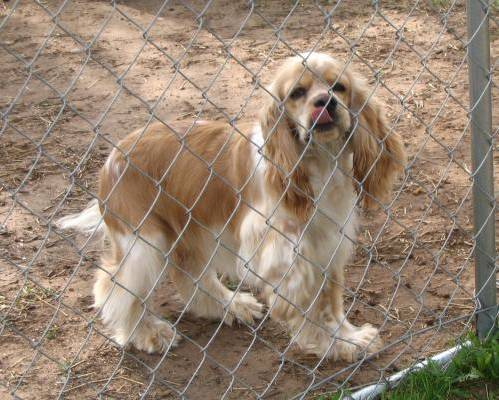
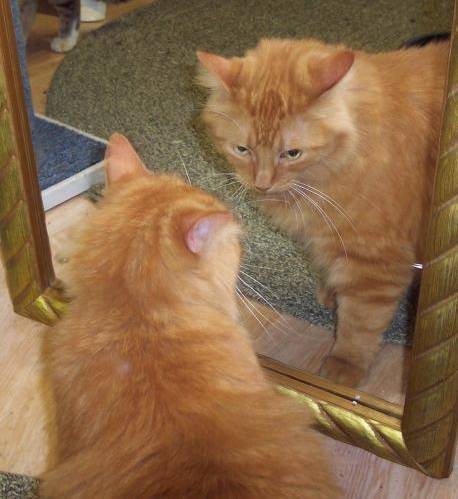
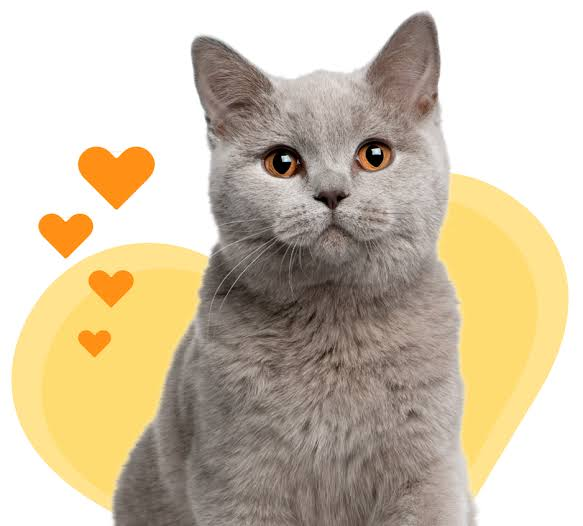
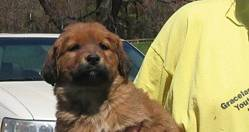
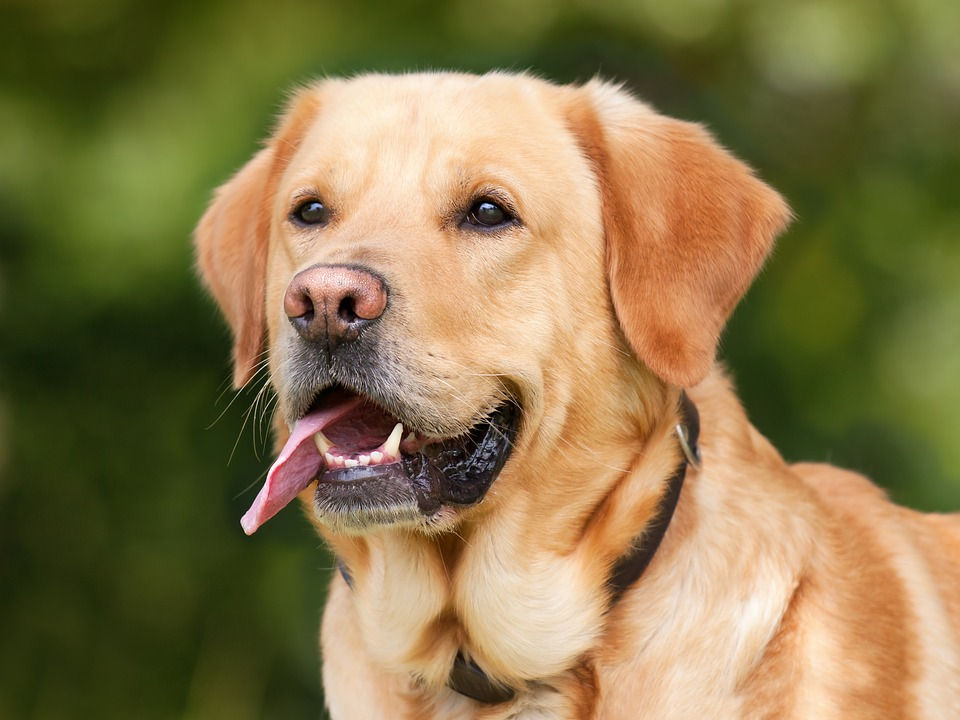
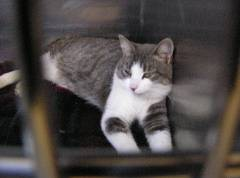
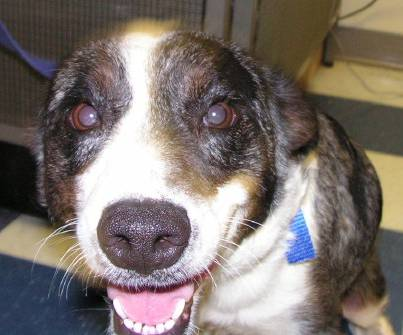
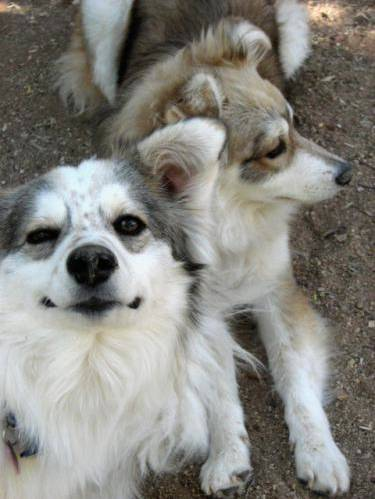
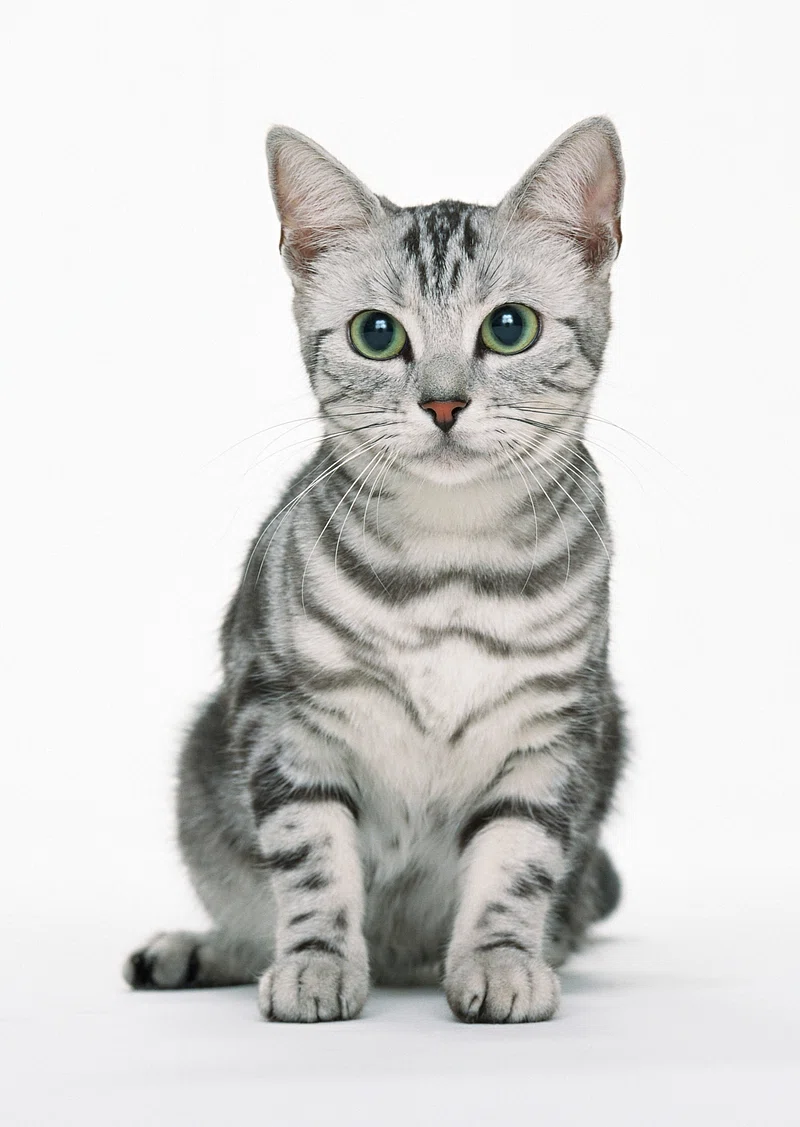
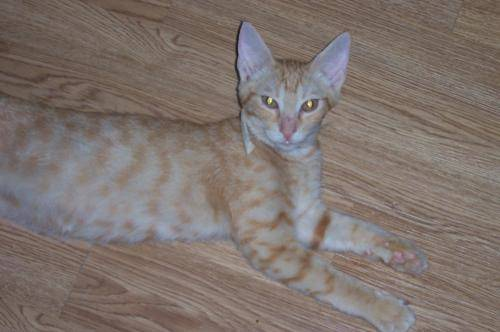
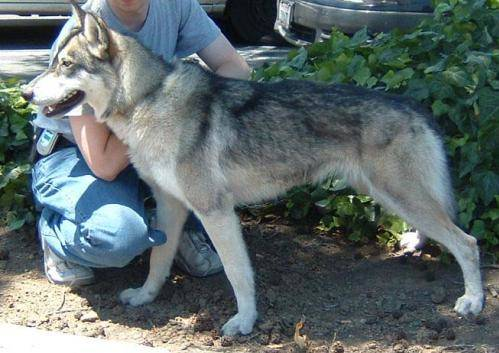
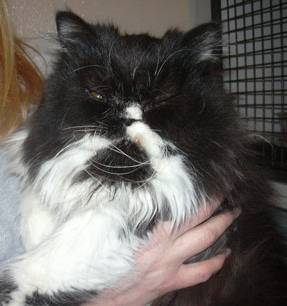
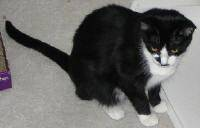
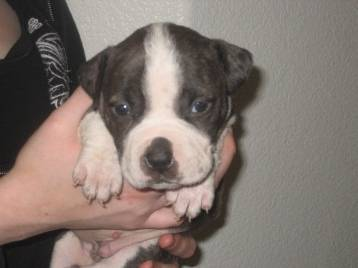
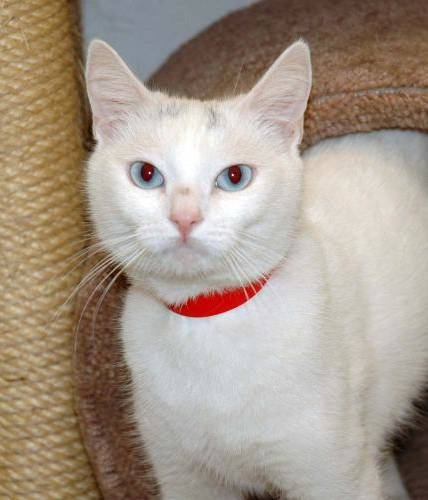
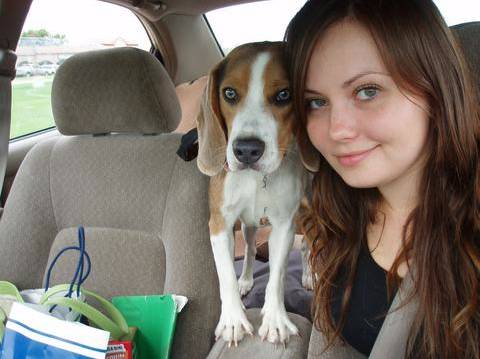
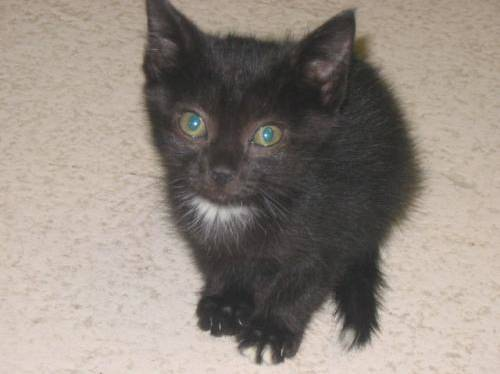
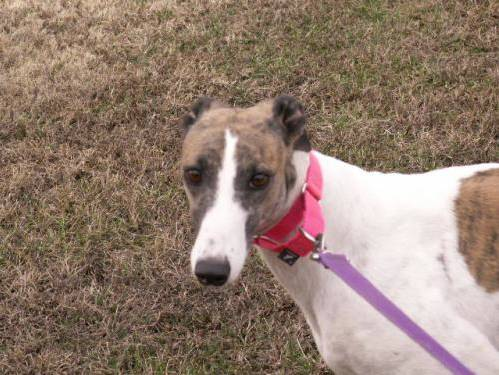
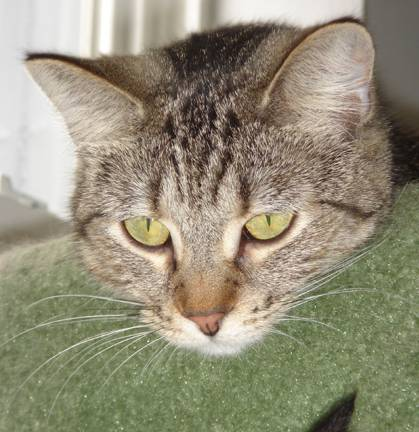
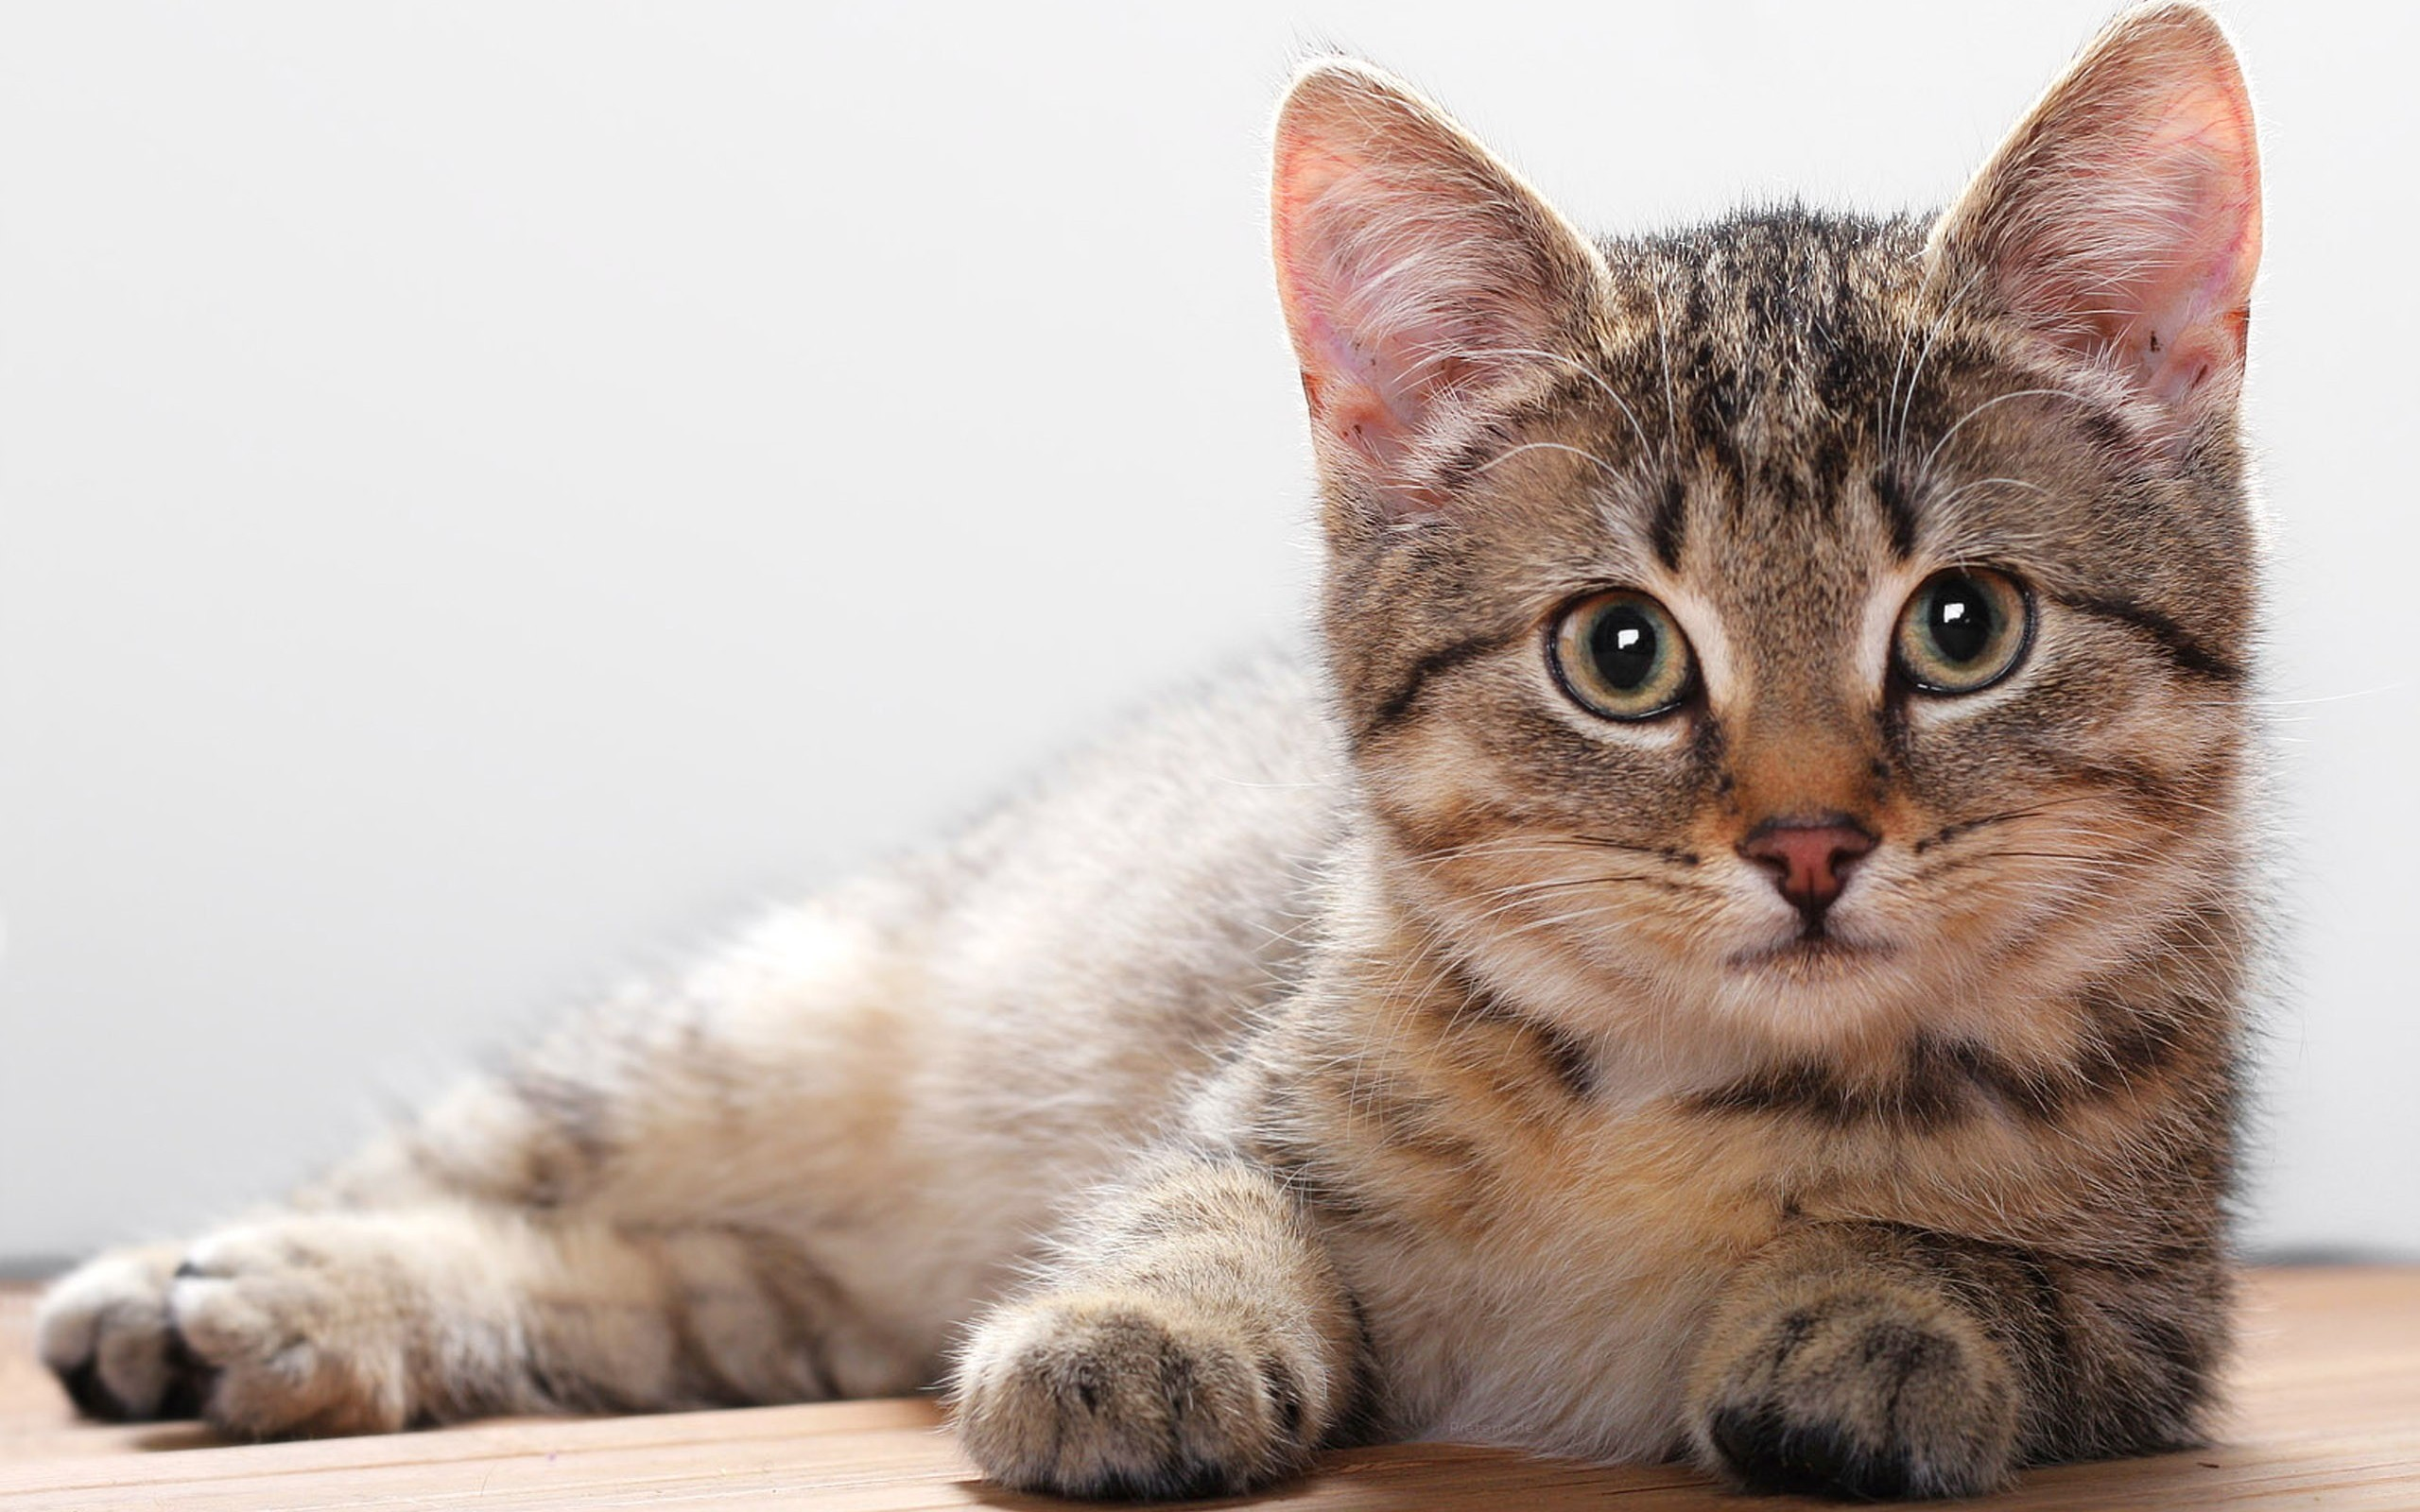
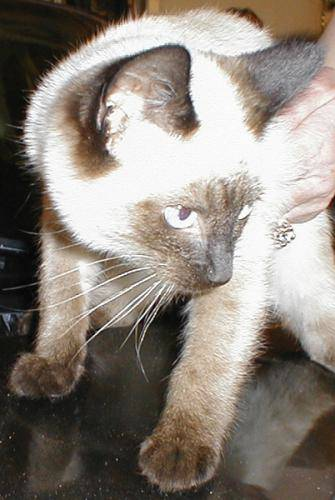

In [18]:
from IPython.display import Image, display
from io import BytesIO
import base64
import os
import numpy as np
import pandas as pd
from keras.preprocessing import image

def img_to_displayable_format(img_path):
    with open(img_path, "rb") as img_file:
        encoded_img = base64.b64encode(img_file.read()).decode('utf-8')
    return f'<img src="data:image/jpeg;base64,{encoded_img}" width="64" height="64"/>'

folder_path = '/content/dataset/single_prediction/'

results = []

# Reverse the dictionary to map from indices back to class names
class_names = {v: k for k, v in training_set.class_indices.items()}

for filename in os.listdir(folder_path):
    if filename.endswith(('.png', '.jpg', '.jpeg', '.webp')):

        img_path = os.path.join(folder_path, filename)
        test_image = image.load_img(img_path, target_size=(64, 64))
        test_image_array = image.img_to_array(test_image)
        test_image_array = np.expand_dims(test_image_array, axis=0)

        result = fin_mod.predict(test_image_array / 255.0)

        predicted_class_index = 1 if result[0] [0] > 0.5 else 0

        prediction = class_names[predicted_class_index]

        img_display = img_to_displayable_format(img_path)
        results.append({'Image': img_display, 'Prediction': prediction})

df_results = pd.DataFrame(results)

from IPython.display import display, HTML
display(HTML(df_results.to_html(escape=False)))
